In [25]:
import yfinance as yf
import pandas as pd

data = yf.download('AAPL', period="1y")
data = data[['Close']]
data.dropna(inplace=True)

[*********************100%***********************]  1 of 1 completed


In [26]:
import numpy as np

# Daily returns
data['returns'] = data['Close'].pct_change()

# Log returns
data['log_returns'] = np.log(data['Close'] / data['Close'].shift(1))

In [27]:
data['volatility'] = data['returns'].rolling(window=20).std()

In [28]:
data['MA_20'] = data['Close'].rolling(20).mean()
data['MA_50'] = data['Close'].rolling(50).mean()

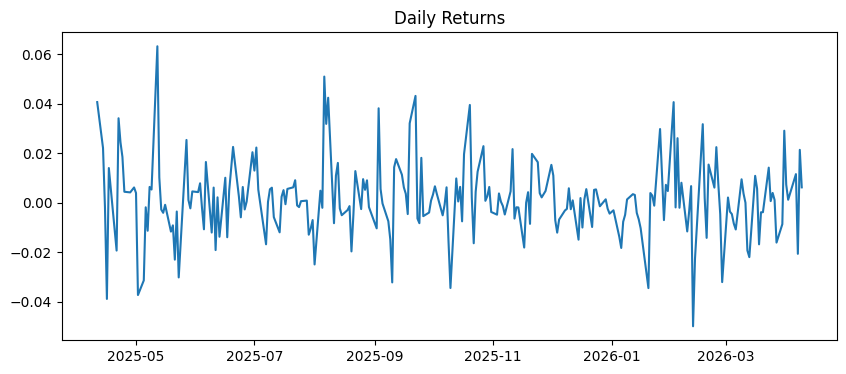

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
plt.plot(data['returns'])
plt.title("Daily Returns")
plt.show()

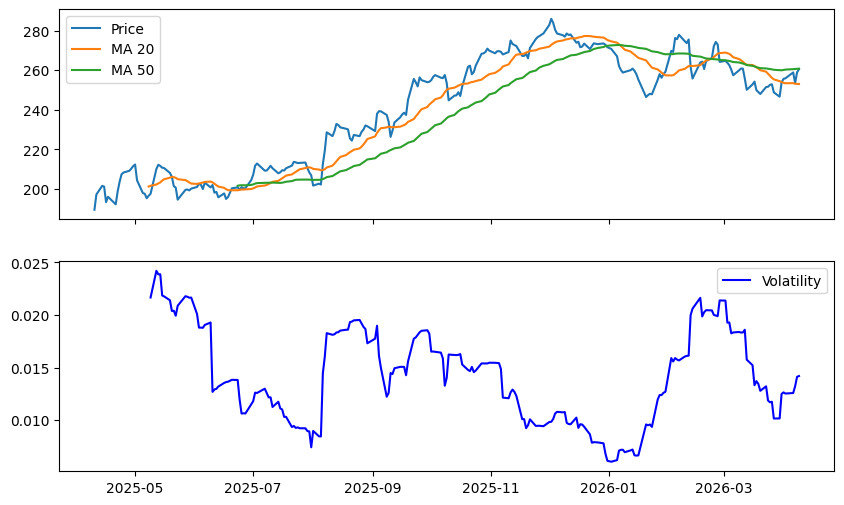

In [30]:
fig, ax = plt.subplots(2, 1, figsize=(10,6), sharex=True)

ax[0].plot(data['Close'], label='Price')
ax[0].plot(data['MA_20'], label='MA 20')
ax[0].plot(data['MA_50'], label='MA 50')
ax[0].legend()

ax[1].plot(data['volatility'], label='Volatility', color='blue')
ax[1].legend()

plt.show()

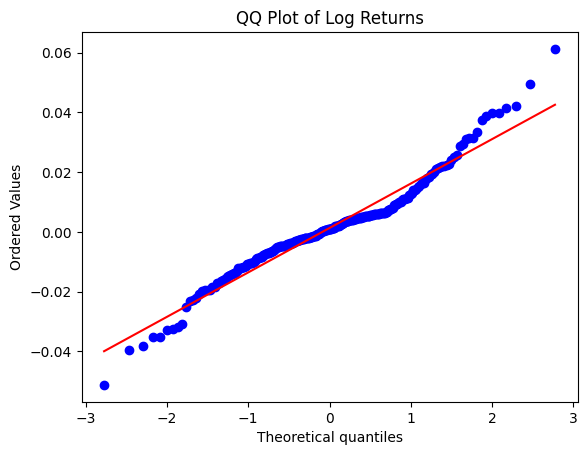

In [31]:
import scipy.stats as stats

stats.probplot(data['log_returns'].dropna(), dist="norm", plot=plt)
plt.title("QQ Plot of Log Returns")
plt.show()

In [39]:
from scipy.stats import skew, kurtosis, jarque_bera

returns = data['log_returns'].replace([np.inf, -np.inf], np.nan).dropna()

print("Mean:", returns.mean())
print("Std Dev:", returns.std())
print("Skewness:", skew(returns))
print("Kurtosis:", kurtosis(returns))
print("Jarque-Bera Test:", jarque_bera(returns))

Mean: 0.0012758281627157544
Std Dev: 0.015133299697611563
Skewness: 0.3097211901529028
Kurtosis: 2.0414055799811504
Jarque-Bera Test: SignificanceResult(statistic=np.float64(47.217098146657406), pvalue=np.float64(5.5838971668166253e-11))


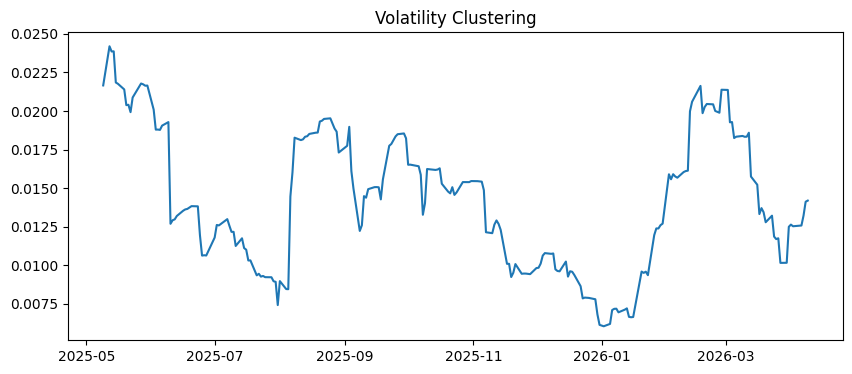

In [40]:
plt.figure(figsize=(10,4))
plt.plot(data['volatility'])
plt.title("Volatility Clustering")
plt.show()

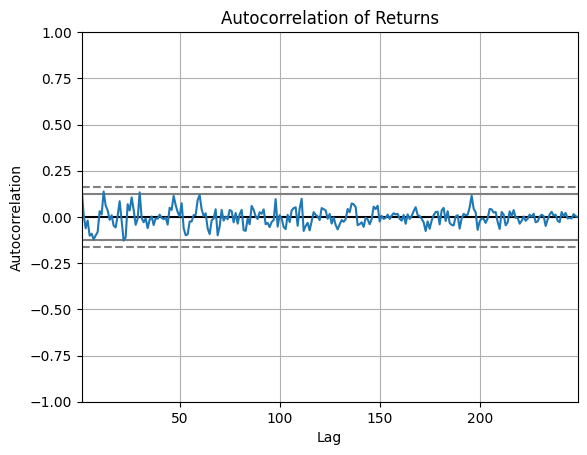

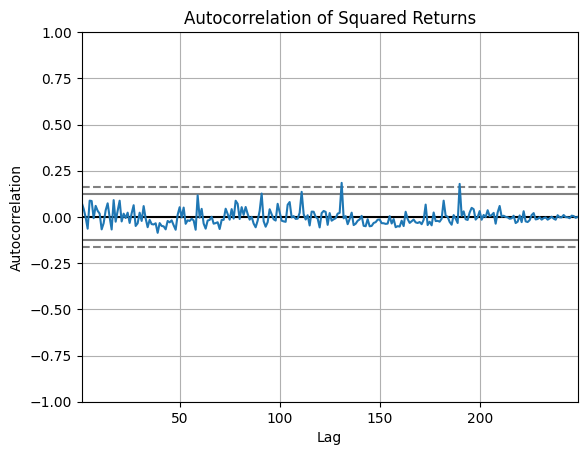

In [41]:
from pandas.plotting import autocorrelation_plot

autocorrelation_plot(data['returns'].dropna())
plt.title("Autocorrelation of Returns")
plt.show()

autocorrelation_plot(data['returns'].dropna()**2)
plt.title("Autocorrelation of Squared Returns")
plt.show()

In [42]:
# Sharpe Ratio (assuming risk-free ~0)
sharpe = returns.mean() / returns.std() * np.sqrt(252)

# Max Drawdown
cum_returns = (1 + data['returns']).cumprod()
peak = cum_returns.cummax()
drawdown = (cum_returns - peak) / peak

max_dd = drawdown.min()

print("Sharpe Ratio:", sharpe)
print("Max Drawdown:", max_dd)

Sharpe Ratio: 1.3383164683103774
Max Drawdown: -0.13798524235020437


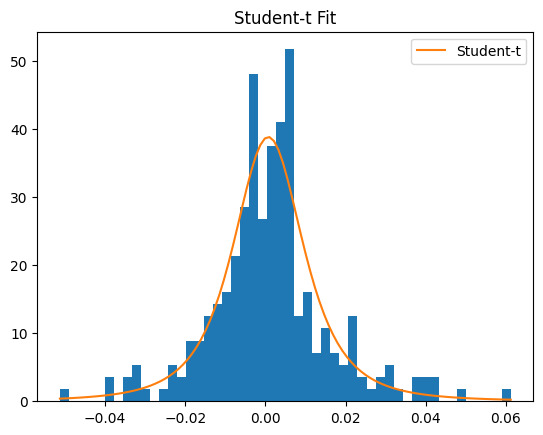

In [43]:
from scipy.stats import t

params = t.fit(returns)

plt.hist(returns, bins=50, density=True)

x = np.linspace(returns.min(), returns.max(), 100)
plt.plot(x, t.pdf(x, *params), label='Student-t')

plt.legend()
plt.title("Student-t Fit")
plt.show()